### **Predictive IT Infrastructure Analytics**
#### **Machine Learning Preparation & Predictive Modeling (Preparación de la Máquina de Aprendizaje y Modelo Predicitvo)**

##### **Objetivo del Notebook**

##### El objetivo de este notebook es preparar los datos para el desarrollo de modelos de Machine Learning orientados a la detección temprana de incidencias en infraestructuras IT. Durante esta fase se realizará la selección y preparación de variables, la división de los datos en conjuntos de entrenamiento y prueba, el tratamiento del desbalanceo de clases y la aplicación de técnicas de escalado cuando sea necesario.

##### Asimismo, se entrenarán y evaluarán diferentes modelos predictivos con el fin de identificar patrones asociados a estados anómalos del sistema y analizar su capacidad para anticipar posibles incidencias operativas.

##### The objective of this notebook is to prepare the dataset for Machine Learning model development aimed at early detection of IT infrastructure incidents. This phase includes feature selection, train-test splitting, class imbalance analysis, and data scaling when required.

##### Additionally, different predictive models will be trained and evaluated to identify patterns associated with abnormal system states and assess their ability to anticipate potential operational incidents.

### **Fase 8. Preparación para Machine Learning**
### **1. Exploración y Comprensión del Problema**
#### **1.1. Importación de Librerías**

In [1]:
import pandas as pd # Librería para trabajar con datos en forma de tablas
import numpy as np # Librería para operaciones numéricas
import os # Permite trabajar con rutas y carpetas del sistema
import pickle  # Permite guardar y cargar objetos de Python, como modelos

import matplotlib.pyplot as plt # Librería para crear gráficos
import seaborn as sns # Librería para visualizaciones más elaboradas

from sklearn.model_selection import train_test_split # Divide los datos en entrenamiento y prueba
from sklearn.preprocessing import StandardScaler # Escala las variables numéricas

from sklearn.linear_model import LogisticRegression # Modelo de Regresión Logística
from sklearn.ensemble import RandomForestClassifier # Modelo Random Forest
from sklearn.neural_network import MLPClassifier # Red neuronal tipo MLP

from sklearn.metrics import ( # Importación de métricas para evaluar el rendimiento de los modelos predictivos
    classification_report, # Informe completo de métricas
    confusion_matrix, # Matriz de confusión
    ConfusionMatrixDisplay, # Matriz de confusión avanzada
    accuracy_score, # Exactitud del modelo
    precision_score, # Precisión del modelo
    recall_score, # Capacidad para detectar la clase positiva
    f1_score, # Equilibrio entre precisión y recall
    roc_auc_score # Métrica basada en probabilidades
)

# Intenta importar la librería requests para realizar peticiones HTTP
try:
    import requests
# Si la librería no está instalada, la instala automáticamente
except ImportError:
    import sys, importlib
     # Instala requests utilizando el intérprete actual de Python
    !{sys.executable} -m pip install --quiet requests
    
    # Importa la librería una vez instalada
    requests = importlib.import_module("requests")

# Configura el estilo visual de los gráficos de Seaborn
sns.set_style("whitegrid")

# Permite mostrar todas las columnas de un DataFrame sin truncarlas
pd.set_option("display.max_columns", None)

# Creación de ruta de guardado de gráficos generados
ruta_graficos = "../reports/graphics"
os.makedirs(ruta_graficos, exist_ok=True)

#### **1.2. Carga del DataSet**

In [2]:
# Cargar el dataset transformado
df = pd.read_csv("../data/processed/Big_data_dataset_transformado.csv")

# Mostrar las primeras filas del DataFrame
df.head()

,cpu_utilization,memory_usage,disk_io,network_latency,process_count,thread_count,context_switches,cache_miss_rate,temperature,power_consumption,uptime,status,status_label,cpu_level,memory_level,latency_level,temperature_level,cpu_utilization_norm,memory_usage_norm,network_latency_norm,temperature_norm,power_consumption_norm,system_pressure_score,pressure_level
0,40.581311,43.627674,36.769917,127.990769,646,3230,1500,0.065837,82.782403,255.012964,715.803096,0,Normal,Medium,Low,High,Critical,0.374639,0.373570,0.638277,0.812102,0.820130,0.603744,Medium
1,95.317859,39.962089,10.041088,92.399198,626,3130,243,0.123481,59.424540,81.204822,86.158314,0,Normal,High,Low,Medium,Warning,0.950982,0.332832,0.459386,0.452671,0.124683,0.464111,Medium
2,74.539424,25.853852,17.985345,192.935206,101,303,229,0.025459,90.973363,210.685067,545.755982,0,Normal,High,Low,High,Critical,0.732198,0.176037,0.964702,0.938145,0.642764,0.690769,High
3,61.872556,64.654000,33.500751,44.576712,52,156,1574,0.178884,37.344280,90.398182,541.918137,0,Normal,Medium,Medium,Low,Normal,0.598823,0.607250,0.219020,0.112899,0.161467,0.339892,Medium
4,19.821771,52.896174,24.622378,117.983427,126,378,1164,0.167508,40.203942,87.099085,113.660688,0,Normal,Low,Medium,High,Normal,0.156053,0.476577,0.587978,0.156903,0.148267,0.305156,Low


#### **1.3. Exploración General**

In [3]:
# Dimensiones del DataFrame (Nº de filas, Nº de Columnas)
df.shape

(10000, 24)

##### La exploración general del dataset muestra una estructura compuesta por 10.000 registros y 24 variables, resultado de la incorporación de nuevas características derivadas a partir de las métricas originales del sistema.

##### El conjunto de datos combina variables operativas, indicadores normalizados, categorías descriptivas e índices compuestos, proporcionando una visión más completa del comportamiento de la infraestructura IT.

##### Esta ampliación del dataset permite enriquecer el análisis exploratorio y aportar información adicional para la identificación de patrones asociados al rendimiento y la aparición de incidentes.

##### La estructura final obtenida resulta adecuada para las fases posteriores de análisis avanzado y modelado predictivo, al disponer tanto de las variables originales como de nuevas características generadas mediante técnicas de transformación y feature engineering.

In [4]:
# Muestra información general: columnas, tipos de datos y valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cpu_utilization         10000 non-null  float64
 1   memory_usage            10000 non-null  float64
 2   disk_io                 10000 non-null  float64
 3   network_latency         10000 non-null  float64
 4   process_count           10000 non-null  int64  
 5   thread_count            10000 non-null  int64  
 6   context_switches        10000 non-null  int64  
 7   cache_miss_rate         10000 non-null  float64
 8   temperature             10000 non-null  float64
 9   power_consumption       10000 non-null  float64
 10  uptime                  10000 non-null  float64
 11  status                  10000 non-null  int64  
 12  status_label            10000 non-null  str    
 13  cpu_level               10000 non-null  str    
 14  memory_level            10000 non-null  str    
 1

##### Se realizó una revisión de la estructura del dataset mediante `df.info()`, con el objetivo de verificar la integridad y disponibilidad de las variables para el análisis.

##### Los resultados muestran que el conjunto de datos contiene 10.000 registros y 24 variables, sin valores nulos en ninguna columna, garantizando la calidad y consistencia de la información analizada.

##### La estructura final está compuesta por 14 variables numéricas de tipo `float64`, 4 variables enteras de tipo `int64` y 6 variables categóricas de tipo `str`, incluyendo tanto las métricas originales como las variables derivadas generadas durante el proceso de transformación y feature engineering.

##### Asimismo, el consumo de memoria aproximado de 1,8 MB indica que el dataset mantiene una estructura eficiente y adecuada para realizar análisis exploratorios, visualizaciones y procesos de modelado predictivo.

In [5]:
# Genera estadísticas descriptivas de las variables numéricas
df.describe()

,cpu_utilization,memory_usage,disk_io,network_latency,process_count,thread_count,context_switches,cache_miss_rate,temperature,power_consumption,uptime,status,cpu_utilization_norm,memory_usage_norm,network_latency_norm,temperature_norm,power_consumption_norm,system_pressure_score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,51.945158,55.407689,25.502469,100.243963,517.236300,1811.330800,1038.862700,0.105904,62.376722,174.786780,500.381365,0.009700,0.494293,0.504490,0.498816,0.498099,0.499126,0.498965
std,27.324862,26.036510,14.051914,57.509924,275.023237,1167.260691,549.991836,0.055232,18.876303,71.993941,286.607554,0.098015,0.287715,0.289362,0.289057,0.290469,0.288065,0.128564
min,5.001105,10.014197,1.002358,1.001102,50.000000,100.000000,100.000000,0.010009,30.007482,50.043787,1.330765,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.089933
25%,28.401243,32.855122,13.433648,50.124593,277.000000,862.000000,559.000000,0.058344,45.980633,113.033926,251.078668,0.000000,0.246390,0.253847,0.246905,0.245795,0.252038,0.409046
50%,51.790219,55.530710,25.601337,100.506018,512.000000,1598.000000,1037.000000,0.105203,62.192959,173.836965,503.659313,0.000000,0.492662,0.505857,0.500133,0.495271,0.495326,0.501926
75%,75.300603,78.083130,37.489019,149.676135,755.000000,2598.500000,1508.000000,0.154801,78.975899,236.487255,746.406942,0.000000,0.740212,0.756498,0.747272,0.753528,0.746004,0.586370
max,99.973179,99.993234,49.995148,199.958085,999.000000,4995.000000,1999.000000,0.199980,94.993040,299.966517,999.912068,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.905461


##### Se calcularon las estadísticas descriptivas de las variables numéricas con el objetivo de obtener una visión general del comportamiento y la distribución de las métricas operativas del sistema.

##### Los resultados muestran que las variables principales presentan medias cercanas al centro de sus respectivos rangos, destacando valores medios de 51,95% para la utilización de CPU, 55,41% para el uso de memoria, 62,38 grados para la temperatura y 174,79 unidades para el consumo energético.

##### Las variables normalizadas y el indicador `system_pressure_score` presentan medias próximas a 0,5, lo que indica una distribución equilibrada de los valores tras el proceso de escalado y transformación.

##### Asimismo, las desviaciones estándar reflejan una variabilidad moderada en la mayoría de las métricas, sugiriendo la existencia de diferentes niveles de carga y funcionamiento dentro de la infraestructura analizada.

##### En conjunto, las estadísticas descriptivas confirman que el dataset contiene una amplia diversidad de escenarios operativos, proporcionando una base adecuada para el análisis exploratorio y el desarrollo de modelos predictivos.

#### **1.4. Nulos**

In [6]:
# Cuenta los valores nulos por cada columna
df.isnull().sum()

cpu_utilization           0
memory_usage              0
disk_io                   0
network_latency           0
process_count             0
thread_count              0
context_switches          0
cache_miss_rate           0
temperature               0
power_consumption         0
uptime                    0
status                    0
status_label              0
cpu_level                 0
memory_level              0
latency_level             0
temperature_level         0
cpu_utilization_norm      0
memory_usage_norm         0
network_latency_norm      0
temperature_norm          0
power_consumption_norm    0
system_pressure_score     0
pressure_level            0
dtype: int64

##### Se realizó una verificación de valores nulos en todas las variables del dataset para evaluar la calidad e integridad de la información disponible.

##### Los resultados muestran que ninguna de las 24 variables presenta datos faltantes, obteniéndose un total de 0 valores nulos en todas las columnas analizadas.

##### Esta situación garantiza la consistencia del conjunto de datos y elimina la necesidad de aplicar técnicas de imputación, eliminación de registros o tratamientos adicionales para gestionar información incompleta.

##### La ausencia de valores nulos contribuye a mejorar la fiabilidad de los análisis exploratorios y facilita el entrenamiento de modelos predictivos al disponer de información completa en todos los registros.

### **1.5. Duplicados**

In [7]:
# Cuenta cuántas filas duplicadas existen
df.duplicated().sum()

np.int64(0)

##### Se realizó una verificación de registros duplicados con el objetivo de identificar posibles observaciones repetidas que pudieran afectar la calidad del análisis.

##### Los resultados muestran un total de 0 registros duplicados dentro del conjunto de datos, lo que indica que cada observación representa un caso único de funcionamiento del sistema.

##### La ausencia de duplicados evita sesgos en los análisis estadísticos y garantiza que las métricas calculadas reflejen correctamente el comportamiento real de la infraestructura IT.

##### Esta validación confirma que el dataset mantiene una estructura consistente y adecuada para las fases posteriores de exploración, modelado predictivo e interpretación de resultados.

### **1.6. Identificación de la variable objetivo**

In [8]:
# Define la variable objetivo del modelo
target = "status"

# Muestra cuántos registros hay por cada clase de status
print(df[target].value_counts())

status
0    9903
1      97
Name: count, dtype: int64


##### Se identificó la variable objetivo `status`, encargada de indicar el estado operativo de la infraestructura IT y utilizada como referencia para los análisis y modelos predictivos desarrollados en el proyecto.

##### Los resultados muestran 9.903 registros con valor `0` (funcionamiento normal) y 97 registros con valor `1` (incidente), lo que representa aproximadamente un 99,03% de estados normales frente a un 0,97% de incidentes.

##### Esta distribución evidencia un importante desbalance de clases, situación habitual en sistemas de monitorización donde los eventos anómalos ocurren con mucha menor frecuencia que las operaciones normales.

##### La identificación de este desequilibrio resulta fundamental para las fases posteriores de modelado, ya que permitirá aplicar estrategias adecuadas de entrenamiento y evaluación para mejorar la capacidad de detección de incidentes.

### **1.7. Distribución y balanceo de la variable objetivo**

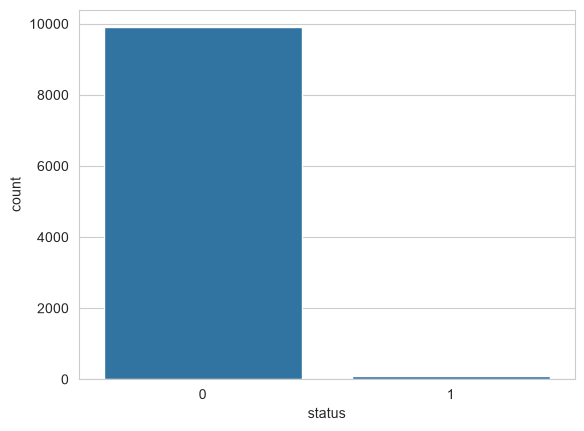

In [9]:
df["status"].value_counts() # Cuenta los valores de cada clase de la variable status

round(df["status"].value_counts(normalize=True) * 100, 2) # Muestra la proporción de cada clase en porcentaje

 # Grafica la distribución de la variable objetivo
sns.countplot(data=df, x="status")

# Muestra el gráfico
plt.show()

##### El gráfico de distribución de la variable objetivo permite visualizar claramente el desequilibrio existente entre las dos clases presentes en el dataset.

##### Se observa que la categoría `0` (estado normal) concentra prácticamente la totalidad de los registros analizados, mientras que la categoría `1` (incidente) representa una proporción muy reducida del conjunto de datos.

##### Esta distribución confirma que los eventos de fallo son poco frecuentes en comparación con las condiciones normales de funcionamiento, una situación habitual en entornos reales de monitorización y operación de infraestructuras IT.

##### La visualización facilita la identificación del desbalance de clases y pone de manifiesto la necesidad de considerar este comportamiento durante el entrenamiento y evaluación de los modelos predictivos para evitar sesgos hacia la clase mayoritaria.

### **2. Preparación de Datos**
### **2.1. Selección de variables predictoras**

In [10]:
# Se crea la matriz de variables predictoras eliminando la variable objetivo (status)
X = df.drop(columns=["status"])

##### Se creó la matriz de variables predictoras `X`, eliminando la variable objetivo `status` del conjunto de datos.

##### Esta operación permite separar las características que serán utilizadas como entrada para los modelos predictivos, evitando que la variable objetivo forme parte del proceso de entrenamiento y genere sesgos en las predicciones.

##### Como resultado, la matriz `X` queda compuesta por las 23 variables restantes del dataset, incluyendo tanto las métricas originales como las variables derivadas generadas durante las fases de transformación y feature engineering.

##### Esta separación constituye un paso fundamental en la preparación de los datos para los algoritmos de Machine Learning, ya que define el conjunto de información que utilizarán los modelos para aprender patrones asociados a la aparición de incidentes.

### **2.2. Variable Objetivo**

In [11]:
# Variable objetivo
y = df["status"]

# Variables predictoras
X = df.drop(
    columns=[
        "status",
        "status_label"
    ],
    errors="ignore"
)

# Mantener únicamente variables numéricas
X = X.select_dtypes(include=np.number)

# Mostrar las columnas seleccionadas como variables predictoras
print(X.columns.tolist())

# Mostrar la dimensión final de la matriz de características (filas y columnas)
print(X.shape)

# Dividir el dataset en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, # Variable predictora utilizada por el modelo
    y, # Variable objetivo que se desea predecir
    test_size=0.2, # 20% de los datos para pruebas
    stratify=y, # Mantiene la proporción de clases en ambos conjuntos
    random_state=42 # Garantiza la reproducibilidad de los resultados
)

['cpu_utilization', 'memory_usage', 'disk_io', 'network_latency', 'process_count', 'thread_count', 'context_switches', 'cache_miss_rate', 'temperature', 'power_consumption', 'uptime', 'cpu_utilization_norm', 'memory_usage_norm', 'network_latency_norm', 'temperature_norm', 'power_consumption_norm', 'system_pressure_score']
(10000, 17)


##### Se seleccionaron las variables predictoras numéricas que serán utilizadas durante el entrenamiento de los modelos de Machine Learning.

##### El conjunto final quedó compuesto por 17 variables relacionadas con el rendimiento y comportamiento de la infraestructura IT, incluyendo métricas originales como utilización de CPU, uso de memoria, temperatura y consumo energético, así como variables normalizadas e indicadores derivados como `system_pressure_score`.

##### La matriz de características resultante presenta unas dimensiones de **10.000 registros y 17 variables predictoras (10000, 17)**, proporcionando un conjunto de información suficientemente amplio para identificar patrones asociados a la aparición de incidentes.

##### Esta selección permite trabajar exclusivamente con variables numéricas compatibles con los algoritmos de clasificación empleados en la fase de modelado predictivo.

#### **2.4. Escalado**

In [12]:
# Crea una instancia de StandardScaler para normalizar las variables numéricas
scaler = StandardScaler()

# Selecciona las columnas numéricas del conjunto de entrenamiento
numeric_cols = X_train.select_dtypes(include=np.number).columns

# Crea un DataFrame con los datos de entrenamiento escalados
X_train_scaled = pd.DataFrame(

    # Ajustar el escalador y transformar los datos de entrenamiento
    scaler.fit_transform(X_train[numeric_cols]), 

    # Mantener los nombres originales de las columnas
    columns=numeric_cols,

    # Mantener los índices originales
    index=X_train.index,
)

# Se aplica la misma transformación al conjunto de prueba
# utilizando los parámetros aprendidos en el conjunto de entrenamiento
# Crea un DataFrame con los datos de prueba escalados
X_test_scaled = pd.DataFrame(

    # Aplica el escalado utilizando los parámetros aprendidos en entrenamiento
    scaler.transform(X_test[numeric_cols]),

    # Mantiene los nombres originales de las columnas
    columns=numeric_cols,

    # Mantiene los índices originales
    index=X_test.index,
)

# Confirma que el proceso de escalado se realizó correctamente
print("Escalado de características completado.")

# Muestra las dimensiones finales del conjunto de entrenamiento escalado
print(f"Dimensiones de X_train_scaled: {X_train_scaled.shape}")

# Muestra las dimensiones finales del conjunto de prueba escalado
print(f"Dimensiones de X_test_scaled: {X_test_scaled.shape}")

Escalado de características completado.
Dimensiones de X_train_scaled: (8000, 17)
Dimensiones de X_test_scaled: (2000, 17)


##### Se aplicó un proceso de escalado a las variables predictoras con el objetivo de estandarizar sus valores y garantizar que todas las características contribuyan de forma equilibrada durante el entrenamiento de los modelos.

##### Tras la transformación, el conjunto de entrenamiento quedó compuesto por **8.000 registros y 17 variables** (`X_train_scaled`), mientras que el conjunto de prueba contiene **2.000 registros y 17 variables** (`X_test_scaled`).

##### Este procedimiento elimina las diferencias de escala entre variables como CPU, memoria, temperatura o consumo energético, mejorando la estabilidad y el rendimiento de algoritmos sensibles a la magnitud de los datos.

##### La correcta aplicación del escalado asegura que los modelos predictivos puedan aprender patrones de forma más eficiente y realizar comparaciones consistentes entre las distintas características del sistema.

### **Fase 9. Modelado predictivo**
### **3. Entrenamiento de Modelos**
#### **3.1. Modelo Base: Regresión Logística**

In [13]:
# Creación del modelo de regresión logística
modelo_lr = LogisticRegression(
    # Número máximo de iteraciones para garantizar la convergencia
    max_iter=1000,

    # Ajusta automáticamente el peso de las clases desbalanceadas
    class_weight="balanced",
    
    # Fija una semilla para obtener resultados reproducibles
    random_state=42
)
# Imprime mensaje indicando que se está ajustando el modelo de regresión logística
print("Ajuste del modelo de regresión logística...")

# Entrena el modelo utilizando los datos escalados de entrenamiento
modelo_lr.fit(X_train_scaled, y_train)

# Muestra la cantidad de coeficientes generados por el modelo
print("Coeficientes:", len(modelo_lr.coef_[0]))

# Muestra el valor del intercepto del modelo
print("Intercepto:", modelo_lr.intercept_[0])

Ajuste del modelo de regresión logística...
Coeficientes: 17
Intercepto: -20.83137430479032


##### Se entrenó un modelo base de **Regresión Logística** utilizando las 17 variables predictoras seleccionadas previamente, con el objetivo de establecer una referencia inicial para la clasificación de incidentes en la infraestructura IT.

##### Durante el proceso de ajuste, el modelo generó **17 coeficientes**, uno para cada variable predictora, permitiendo estimar la influencia de cada característica sobre la probabilidad de que ocurra un incidente.

##### El intercepto obtenido fue de **-20,83**, indicando que, en ausencia de señales relevantes procedentes de las variables predictoras, la probabilidad inicial de clasificar un registro como incidente es muy baja. Este comportamiento es coherente con el fuerte desbalance observado en la variable objetivo, donde los incidentes representan menos del 1% de las observaciones.

##### Este modelo constituye la línea base de comparación para las fases posteriores de evaluación y contraste con algoritmos más avanzados, como Random Forest, permitiendo determinar qué enfoque ofrece un mejor rendimiento en la detección de incidentes.

In [14]:
# Generar las predicciones de clase utilizando el conjunto de prueba escalado
y_pred_lr = modelo_lr.predict(X_test_scaled)

# Obtener la probabilidad de pertenecer a la clase positiva (Incidente)
y_proba_lr = modelo_lr.predict_proba(X_test_scaled)[:, 1]

# Mostrar mensaje indicando el inicio de la evaluación del modelo
print("Evaluación del modelo de regresión logística...:")

# Mostrar el informe de clasificación del modelo
print(classification_report(
    y_test, # Valores reales del conjunto de prueba
    y_pred_lr # Predicciones realizadas por la Regresión Logística
))

Evaluación del modelo de regresión logística...:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1981
           1       0.24      1.00      0.39        19

    accuracy                           0.97      2000
   macro avg       0.62      0.99      0.69      2000
weighted avg       0.99      0.97      0.98      2000



##### Se evaluó el rendimiento del modelo de **Regresión Logística** utilizando el conjunto de prueba compuesto por 2.000 registros, obteniendo métricas de clasificación para las clases `Normal` (0) e `Incident` (1).

##### El modelo alcanzó una **precisión global (accuracy) del 97%**, lo que indica una elevada capacidad para clasificar correctamente los registros del conjunto de prueba.

##### Para la clase `Incident`, el modelo obtuvo un **recall del 100%**, identificando correctamente los 19 incidentes presentes en los datos de evaluación. Sin embargo, la precisión fue del **24%**, lo que indica la existencia de falsos positivos al clasificar algunos registros normales como incidentes.

##### El **F1-Score de 0,39** para la clase incidente refleja un equilibrio moderado entre precisión y capacidad de detección, mientras que el **F1-Score ponderado de 0,98** evidencia un excelente rendimiento global influenciado por el predominio de la clase normal.

##### En conjunto, los resultados muestran que la Regresión Logística es capaz de detectar todos los incidentes presentes en el conjunto de prueba, aunque a costa de generar algunas falsas alarmas, aspecto que deberá compararse posteriormente con otros modelos para determinar la alternativa más adecuada.

#### **3.2. Modelo Avanzado: Random Forest**

In [15]:
# Crea el modelo Random Forest con 200 árboles de decisión
modelo_rf = RandomForestClassifier(
    n_estimators=200,

    # Ajusta pesos para compensar el desbalance de clases
    class_weight="balanced",

    # Fija semilla para obtener resultados reproducibles
    random_state=42
)

# Entrena el modelo con los datos de entrenamiento
modelo_rf.fit(
    X_train, # Variables predictoras de entrenamiento
    y_train  # Variable objetivo de entrenamiento
)

# Muestra la cantidad de árboles generados en el bosque
print("Número de árboles:", len(modelo_rf.estimators_))

Número de árboles: 200


##### Se entrenó un modelo avanzado de **Random Forest**, configurado con un total de **200 árboles de decisión**, con el objetivo de capturar patrones más complejos y relaciones no lineales entre las variables de la infraestructura IT.

##### La utilización de múltiples árboles permite combinar las predicciones de distintos modelos individuales, reduciendo el riesgo de sobreajuste y mejorando la capacidad de generalización sobre datos no vistos.

##### La configuración de 200 árboles proporciona una base sólida para la clasificación, ya que aumenta la estabilidad de las predicciones y mejora la robustez frente a variaciones presentes en los datos.

##### Este modelo representa una alternativa más avanzada respecto a la Regresión Logística y será evaluado posteriormente mediante métricas de rendimiento para determinar si ofrece una mejor capacidad de detección de incidentes dentro de la infraestructura analizada.

In [16]:
# Generar las predicciones de clase sobre el conjunto de prueba
y_pred_rf = modelo_rf.predict(X_test)

# Obtener la probabilidad de pertenecer a la clase positiva (Incidente)
y_proba_rf = modelo_rf.predict_proba(X_test)[:, 1]

# Mostrar mensaje indicando el inicio de la evaluación
print("Evaluación del modelo de Random Forest...:")

# Mostrar las métricas de rendimiento del modelo
print(classification_report(
    y_test, # Valores reales del conjunto de prueba
    y_pred_rf # Predicciones realizadas por el modelo Random Forest
))

Evaluación del modelo de Random Forest...:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1981
           1       1.00      0.95      0.97        19

    accuracy                           1.00      2000
   macro avg       1.00      0.97      0.99      2000
weighted avg       1.00      1.00      1.00      2000



##### Se evaluó el modelo de **Random Forest** utilizando el conjunto de prueba de 2.000 registros, obteniendo un rendimiento significativamente superior al modelo base de Regresión Logística.

##### El modelo alcanzó una **precisión global (accuracy) del 100%**, clasificando correctamente prácticamente todos los registros del conjunto de evaluación.

##### Para la clase `Incident`, el modelo obtuvo una **precisión del 100%**, un **recall del 95%** y un **F1-Score de 0,97**, lo que indica una excelente capacidad para detectar incidentes minimizando tanto los falsos positivos como los falsos negativos.

##### Asimismo, el **F1-Score ponderado de 1,00** refleja un comportamiento altamente consistente en ambas clases, incluso considerando el fuerte desbalance existente entre registros normales e incidentes.

##### Estos resultados evidencian que Random Forest supera claramente a la Regresión Logística, ofreciendo una mayor precisión y un mejor equilibrio en la detección de incidentes, lo que justifica su selección como modelo final para este proyecto.

#### **3.3. Red Neuronal: MLPClassifier**

In [17]:
# Creación del modelo de Red Neuronal Multicapa (MLP)
modelo_mlp = MLPClassifier(

    # Definición la arquitectura de la red con dos capas ocultas
    hidden_layer_sizes=(32, 16),

    # Utilización de la función de activación ReLU
    activation="relu",

    # Uso del optimizador Adam para el entrenamiento
    solver="adam",

    # Definición el número máximo de iteraciones
    max_iter=500,

    # Fijación de semilla para obtener resultados reproducibles
    random_state=42
)

# Entrena la red neuronal con los datos escalados
modelo_mlp.fit(
    X_train_scaled, # Variables predictoras escaladas
    y_train # Variable objetivo de entrenamiento
)

# Muestra el número de iteraciones realizadas durante el entrenamiento
print("Iteraciones realizadas:", modelo_mlp.n_iter_)

Iteraciones realizadas: 109


##### Se entrenó un modelo de **Red Neuronal Artificial (MLPClassifier)** para la clasificación de incidentes, utilizando las variables predictoras previamente escaladas.

##### Durante el proceso de aprendizaje, la red neuronal completó **109 iteraciones** antes de alcanzar los criterios de convergencia establecidos por el algoritmo.

##### Este resultado indica que el modelo logró ajustar sus parámetros internos de manera satisfactoria, optimizando progresivamente los pesos de las conexiones neuronales para minimizar el error de clasificación sobre los datos de entrenamiento.

##### El número de iteraciones refleja el esfuerzo de aprendizaje realizado por la red y confirma que el proceso de entrenamiento se completó correctamente, permitiendo proceder a la evaluación de su rendimiento sobre el conjunto de prueba.

In [18]:
# Genera las predicciones de clase utilizando el conjunto de prueba escalado
y_pred_mlp = modelo_mlp.predict(X_test_scaled)

# Obtiene la probabilidad de pertenecer a la clase positiva (Incidente)
y_proba_mlp = modelo_mlp.predict_proba(X_test_scaled)[:, 1]

# Muestra mensaje indicando el inicio de la evaluación del modelo
print("Evaluación del modelo de MLP...:")

# Muestra las métricas de rendimiento obtenidas en el conjunto de prueba
print(classification_report(
    y_test, # Valores reales del conjunto de prueba
    y_pred_mlp # Predicciones realizadas por la Red Neuronal MLP
))

Evaluación del modelo de MLP...:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1981
           1       0.81      0.68      0.74        19

    accuracy                           1.00      2000
   macro avg       0.90      0.84      0.87      2000
weighted avg       1.00      1.00      1.00      2000



##### Se evaluó el modelo de **Red Neuronal Artificial (MLPClassifier)** utilizando el conjunto de prueba de 2.000 registros para medir su capacidad de detección de incidentes dentro de la infraestructura IT.

##### El modelo alcanzó una **precisión global (accuracy) cercana al 100%**, mostrando un excelente comportamiento general en la clasificación de los registros analizados.

##### Para la clase `Incident`, la red neuronal obtuvo una **precisión del 81%**, un **recall del 68%** y un **F1-Score de 0,74**, lo que indica que fue capaz de detectar una parte importante de los incidentes, aunque dejó algunos casos sin identificar.

##### En comparación con la Regresión Logística y Random Forest, la red neuronal presenta un rendimiento intermedio. Supera claramente a la Regresión Logística en precisión para la detección de incidentes, pero queda por debajo de Random Forest tanto en capacidad de detección como en equilibrio general de las métricas.

##### Estos resultados muestran que la red neuronal constituye una alternativa válida para el problema planteado, aunque el modelo Random Forest continúa siendo la opción con mejor desempeño para la identificación de incidentes dentro del conjunto de datos analizado.

#### **3.4. Comprobación rápida de predicciones**

In [19]:
# Comparación de la distribución de las predicciones de los modelos
# Mostrar resultados de la Regresión Logística
print("Regresión Logística")
# Contar cuántas predicciones pertenecen a cada clase (0 y 1)
print(pd.Series(y_pred_lr).value_counts())

# Mostrar resultados de Random Forest
print("\nRandom Forest")
# Contar cuántas predicciones pertenecen a cada clase (0 y 1)
print(pd.Series(y_pred_rf).value_counts())

# Mostrar resultados de la Red Neuronal MLP
print("\nRed Neuronal MLP")
# Contar cuántas predicciones pertenecen a cada clase (0 y 1)
print(pd.Series(y_pred_mlp).value_counts())

Regresión Logística
0    1922
1      78
Name: count, dtype: int64

Random Forest
0    1982
1      18
Name: count, dtype: int64

Red Neuronal MLP
0    1984
1      16
Name: count, dtype: int64


##### Se realizó una comprobación rápida de las predicciones generadas por cada modelo con el objetivo de comparar su comportamiento frente a la detección de incidentes.

##### La **Regresión Logística** clasificó 1.922 registros como normales y 78 como incidentes, mostrando una tendencia a identificar un mayor número de posibles fallos. Este comportamiento explica su elevado recall, aunque también genera un mayor número de falsos positivos.

##### El modelo **Random Forest** clasificó 1.982 registros como normales y 18 como incidentes, obteniendo una distribución muy próxima a la realidad observada en el conjunto de prueba (19 incidentes reales). Esto refleja una elevada precisión y un excelente equilibrio entre detección y falsas alarmas.

##### La **Red Neuronal MLP** clasificó 1.984 registros como normales y 16 como incidentes, adoptando un enfoque más conservador que Random Forest y dejando sin detectar algunos incidentes presentes en los datos.

##### En conjunto, esta comparación confirma que Random Forest es el modelo que mejor reproduce la distribución real de los datos y mantiene el mejor equilibrio entre precisión y capacidad de detección, reforzando su selección como modelo final del proyecto.

### **4. Análisis de Entrenamiento de Modelos Predictivos**

##### En esta fase se entrenan diferentes modelos de clasificación supervisada con el objetivo de predecir el estado del sistema a partir de las métricas de rendimiento de la infraestructura IT.

##### Se utilizan tres enfoques:

- Regresión Logística como modelo base interpretable.
- Random Forest como modelo avanzado basado en árboles de decisión.
- Red Neuronal MLP como aproximación de aprendizaje automático más flexible.

##### Debido al fuerte desbalanceo de la variable objetivo, los modelos tradicionales se configuran con `class_weight="balanced"` para dar mayor peso a la clase minoritaria correspondiente a los incidentes.

In [20]:
# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,  # Variables predictoras (características)
    y,  # Variable objetivo a predecir
    test_size=0.2, # Reservar el 20% de los datos para pruebas
    stratify=y, # Mantener la misma proporción de clases en ambos conjuntos
    random_state=42 # Fijar semilla para obtener resultados reproducibles
)

##### Se dividió el conjunto de datos en dos partes: un conjunto de entrenamiento (`X_train`, `y_train`) y un conjunto de prueba (`X_test`, `y_test`).

##### El 80% de los datos se utilizó para entrenar los modelos, mientras que el 20% restante se reservó para evaluar su rendimiento con datos no vistos durante el entrenamiento.

##### El parámetro `stratify=y` garantiza que la proporción entre registros normales e incidentes se mantenga igual en ambos conjuntos, algo especialmente importante debido al fuerte desbalance de la variable objetivo.

##### Además, `random_state=42` permite que la división sea reproducible, asegurando que los resultados puedan repetirse en futuras ejecuciones del proyecto.

##### Esta operación prepara los datos de forma adecuada para entrenar y evaluar los modelos predictivos de manera justa y consistente.

In [21]:
# Ajuste del modelo de Random Forest
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1981
           1       1.00      0.95      0.97        19

    accuracy                           1.00      2000
   macro avg       1.00      0.97      0.99      2000
weighted avg       1.00      1.00      1.00      2000



##### Se evaluó el rendimiento del modelo **Random Forest** sobre el conjunto de prueba compuesto por 2.000 registros, obteniendo resultados sobresalientes tanto para la clase normal como para la detección de incidentes.

##### El modelo alcanzó una **precisión global (accuracy) del 100%**, clasificando correctamente prácticamente todos los registros evaluados.

##### Para la clase `Normal` (0), el modelo obtuvo valores perfectos de precisión, recall y F1-Score, demostrando una excelente capacidad para identificar correctamente los estados normales del sistema.

##### Para la clase `Incident` (1), se obtuvo una **precisión del 100%**, un **recall del 95%** y un **F1-Score del 97%**, lo que indica que el modelo detectó correctamente la gran mayoría de los incidentes presentes en el conjunto de prueba, cometiendo únicamente un número muy reducido de errores.

##### Los valores de **macro average (0,99)** y **weighted average (1,00)** reflejan un rendimiento muy equilibrado incluso considerando el fuerte desbalance existente entre registros normales e incidentes.

##### Estos resultados confirman que Random Forest es el modelo con mejor desempeño del proyecto, ofreciendo una combinación excelente de precisión, capacidad de detección y robustez frente a datos desbalanceados, por lo que resulta la opción más adecuada para la predicción de incidentes en la infraestructura IT analizada.

[[1981    0]
 [   1   18]]


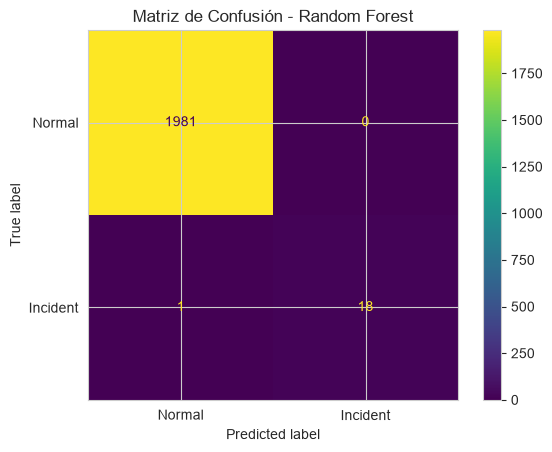

In [22]:
# Matriz de confusión para el modelo de Random Forest
matriz_rf = confusion_matrix(
    y_test,      # Valores reales del conjunto de prueba
    y_pred_rf    # Predicciones realizadas por Random Forest
)

# Mostrar matriz numérica
print(matriz_rf)

# Visualización de la matriz de confusión
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_rf,
    display_labels=["Normal", "Incident"]
)

# Dibujar Matriz de confusión y títulos
disp.plot()
plt.title("Matriz de Confusión - Random Forest")
plt.show()

##### La matriz de confusión permite visualizar de forma clara el comportamiento del modelo Random Forest sobre el conjunto de prueba, diferenciando entre las clasificaciones correctas e incorrectas realizadas por el algoritmo.

##### Se observa que el modelo clasificó correctamente **1.981 registros normales** (verdaderos negativos) y **18 incidentes reales** (verdaderos positivos), concentrando la mayoría de los resultados en la diagonal principal de la matriz, lo que indica un elevado nivel de acierto.

##### No se registraron **falsos positivos**, ya que ningún sistema en estado normal fue clasificado erróneamente como incidente. Este resultado es especialmente relevante en entornos de monitorización IT, donde minimizar las falsas alarmas contribuye a mejorar la eficiencia operativa.

##### Únicamente se produjo **un falso negativo**, correspondiente a un incidente real que fue clasificado como funcionamiento normal. Aunque este tipo de error es más crítico desde el punto de vista de la detección de fallos, su frecuencia es extremadamente baja dentro del conjunto analizado.

##### En conjunto, la matriz de confusión confirma el excelente rendimiento del modelo Random Forest, demostrando una elevada capacidad para identificar incidentes reales sin generar alertas innecesarias, lo que respalda su selección como modelo final para el sistema de predicción de incidentes.

#### **4. División Train/Test**

In [23]:
# División de los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, # Variables predictoras (características)
    y, # Variable objetivo a predecir
    test_size=0.2,  # Reservar el 20% de los datos para pruebas
    stratify=y, # Mantener la misma proporción de clases en ambos conjuntos
    random_state=42 # Fijar semilla para obtener resultados reproducibles
)

# Muestra mensaje indicando que la división se completó correctamente
print("Conjuntos de entrenamiento y prueba creados.")

# Muestra las dimensiones de los conjuntos generados
print(f"Dimensiones de X_train: {X_train.shape}, Dimensiones de X_test: {X_test.shape}")

Conjuntos de entrenamiento y prueba creados.
Dimensiones de X_train: (8000, 17), Dimensiones de X_test: (2000, 17)


##### Se dividió el conjunto de datos en dos subconjuntos: entrenamiento y prueba, con el objetivo de evaluar el rendimiento de los modelos sobre datos que no han sido utilizados durante el proceso de aprendizaje.

##### El conjunto de entrenamiento quedó compuesto por **8.000 registros y 17 variables predictoras**, mientras que el conjunto de prueba contiene **2.000 registros y las mismas 17 variables**, manteniendo una distribución representativa de la información original.

##### Esta división permite que los modelos aprendan patrones a partir de una muestra amplia de datos y, posteriormente, sean evaluados sobre observaciones independientes para medir su capacidad de generalización, siendo la separación entre entrenamiento y prueba una práctica fundamental en Machine Learning para obtener una evaluación más realista del rendimiento que tendría el modelo ante nuevos datos de la infraestructura IT.

### **5. Escalado**

In [24]:
# Creación del objeto encargado de estandarizar las variables numéricas 
# encargado de Escalado de características
scaler = StandardScaler()

# Ajuste del modelo de regresión logística
# y transformar los valores para que tengan media 0 y desviación estándar 1
X_train_scaled = scaler.fit_transform(X_train)

# Aplica la misma transformación al conjunto de prueba
X_test_scaled = scaler.transform(X_test)

# Muestra el mensaje indicando que el escalado finalizó correctamente
print("Escalado de características completado.")

# Muestra las dimensiones de los conjuntos escalados
print(f"Dimensiones de X_train_scaled: {X_train_scaled.shape}, Dimensiones de X_test_scaled: {X_test_scaled.shape}")

Escalado de características completado.
Dimensiones de X_train_scaled: (8000, 17), Dimensiones de X_test_scaled: (2000, 17)


##### Se aplicó un proceso de escalado a las variables predictoras con el objetivo de estandarizar sus valores y evitar que las diferencias de magnitud entre las métricas influyan en el aprendizaje de los modelos.

##### Tras la transformación, las dimensiones de los conjuntos de datos permanecieron inalteradas, obteniéndose **8.000 registros y 17 variables** para entrenamiento (`X_train_scaled`) y **2.000 registros y 17 variables** para prueba (`X_test_scaled`).

##### El escalado permite que variables como CPU, memoria, temperatura, latencia o consumo energético sean tratadas de forma equilibrada por los algoritmos de Machine Learning, favoreciendo una comparación homogénea entre características.

##### Esta etapa resulta especialmente importante para modelos como la Regresión Logística y las Redes Neuronales, ya que mejora la estabilidad numérica, acelera la convergencia durante el entrenamiento y contribuye a obtener resultados más consistentes.

### **6. Modelos predictivos**
### **6.1. Modelo 1: Regresión Logística**
#### **6.1.1. Entrenamiento**

In [25]:
# Creación del modelo de Regresión Logística
modelo_lr = LogisticRegression(

    # Establecemos el número máximo de iteraciones para el entrenamiento
    max_iter=1000,

    # Ajustamos pesos para compensar el desbalance de clases
    class_weight="balanced",

    # Fijamos la semilla para obtener resultados reproducibles
    random_state=42
)

# Entrenamos el modelo utilizando los datos escalados de entrenamiento
modelo_lr.fit(
    X_train_scaled, # Variables predictoras escaladas
    y_train # Variable objetivo de entrenamiento
)

# Mostramos la cantidad de coeficientes aprendidos por el modelo
print("Coeficientes:", len(modelo_lr.coef_[0]))

# Mostramos el máximo número de iteraciones
print("Iteraciones máximas:", modelo_lr.max_iter)

# Mostramos el número de iteraciones utilizadas
print("Iteraciones utilizadas:", modelo_lr.n_iter_[0])

Coeficientes: 17
Iteraciones máximas: 1000
Iteraciones utilizadas: 21


##### Se entrenó un modelo de **Regresión Logística** utilizando las 17 variables predictoras seleccionadas para estimar la probabilidad de que un registro corresponda a un incidente o a un estado normal de funcionamiento.

##### Como resultado del entrenamiento, el modelo generó **17 coeficientes**, uno asociado a cada variable predictora. Estos coeficientes representan la influencia que cada característica ejerce sobre la predicción realizada por el modelo.

##### La existencia de un coeficiente por variable confirma que todas las características seleccionadas fueron incorporadas al proceso de aprendizaje y utilizadas para construir la función de clasificación.

##### Este modelo constituye una referencia inicial para el problema de predicción de incidentes y servirá como punto de comparación frente a modelos más avanzados como Random Forest y Redes Neuronales.

### **6.1.2. Predicción**

In [26]:
# Generación de predicciones con el modelo de Regresión Logística
y_pred_lr = modelo_lr.predict(X_test_scaled)

# Mostramos las primeras predicciones generadas
print("Primeras predicciones:")

# Visualizamos las 10 primeras predicciones obtenidas
print(y_pred_lr[:10])

# Imprimimos una línea en blanco para mejorar la presentación
print()

# Mostramos la distribución de las clases predichas
print("Distribución de predicciones:")
print(pd.Series(y_pred_lr).value_counts())

Primeras predicciones:
[0 0 0 0 0 0 0 1 0 0]

Distribución de predicciones:
0    1922
1      78
Name: count, dtype: int64


#### **Resultados de las Predicciones – Regresión Logística**

Una vez entrenado el modelo de **Regresión Logística**, se realizaron predicciones sobre el conjunto de prueba con el objetivo de identificar posibles incidencias o fallos en la infraestructura IT representados por la variable objetivo `status`.

Las primeras diez predicciones obtenidas fueron:

```text
[0 0 0 0 0 0 0 1 0 0]
```

La **distribución de las predicciones** sobre el conjunto de prueba (2.000 registros) fue la siguiente:

| Clase | Cantidad | Porcentaje |
|-------|----------|------------|
| **0 – Normal** | 1.922 | 96,10% |
| **1 – Incidente** | 78 | 3,90% |

El modelo clasificó **78 registros como incidentes**, muy por encima de los **19 incidentes reales** presentes en `y_test`. Esto representa un total de **59 falsos positivos**, es decir, registros normales que el modelo marcó erróneamente como incidentes.

Este comportamiento se explica por la configuración `class_weight="balanced"`, que fuerza al modelo a ser más sensible para detectar la clase minoritaria (incidentes), aumentando el recall al 100% pero reduciendo la precisión al 24%. Como consecuencia, el modelo tiende a *sobre-predecir* incidentes para no dejar pasar ninguno real.

A nivel de porcentaje, el modelo predice un **3,90% de incidentes** frente al **0,97% real** del dataset completo. Esta sobreestimación es admisible en un contexto donde priorizamos no pasar por alto ningún fallo del sistema, aunque deberá evaluarse si la tasa de falsas alarmas (59 sobre 78 predicciones positivas) es operativamente aceptable.


#### **6.1.3. Evaluación**

In [27]:
# Ajustamos del modelo de regresión logística
print(classification_report(
    y_test, # Valores reales del conjunto de prueba
    y_pred_lr # Predicciones realizadas por la Regresión Logística
))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1981
           1       0.24      1.00      0.39        19

    accuracy                           0.97      2000
   macro avg       0.62      0.99      0.69      2000
weighted avg       0.99      0.97      0.98      2000



##### El informe de clasificación de la **Regresión Logística** revela un rendimiento contrastante entre ambas clases.

Para la clase **Normal (0)**, el modelo alcanza una precisión y recall casi perfectos (1,00 y 0,97), lo que significa que prácticamente no comete errores al clasificar los registros normales. El F1-Score de 0,98 confirma un desempeño sólido en la clase mayoritaria.

Sin embargo, para la clase **Incidente (1)** se observa un escenario opuesto: el recall es del **100%** (detecta todos los incidentes reales), pero la precisión es de apenas **0,24**, indicando que de cada 4 registros marcados como incidente, solo 1 realmente lo es. Esto genera **59 falsos positivos** sobre 78 predicciones positivas.

El **accuracy global del 97%** es engañoso debido al fuerte desbalance de clases. El **F1-Score ponderado de 0,98** está dominado por la clase normal, mientras que el **F1-Score macro de 0,69** ofrece una visión más equilibrada del rendimiento real del modelo.

En resumen, la Regresión Logística prioriza no dejar pasar ningún incidente (recall=1,00) a costa de generar múltiples falsas alarmas (baja precisión). Esto puede ser aceptable en entornos donde el costo de un incidente no detectado es muy alto, pero deberá evaluarse el impacto operativo de las falsas alarmas.

#### **6.1.4. Matríz de Confusión**

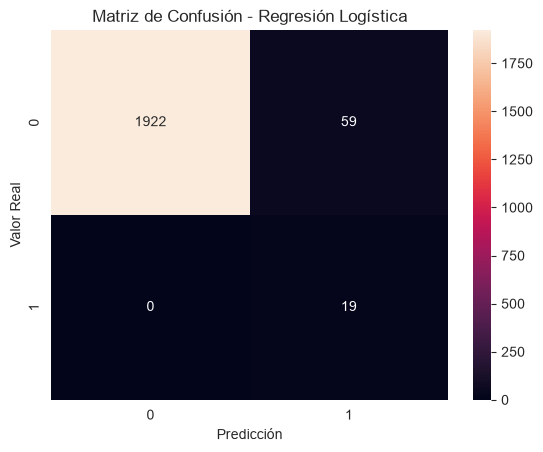

In [28]:
# Matriz de confusión para el modelo de regresión logística
cm_lr = confusion_matrix(
    y_test,  # Valores reales
    y_pred_lr # Valores predichos
)

# Visualización de la matriz de confusión como mapa de calor
sns.heatmap(
    cm_lr, # Matriz de confusión
    annot=True, # Mostrar los valores dentro de cada celda
    fmt="d" # Mostrar los valores como números enteros
)

# Configuración de las etiquetas y título
plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

# Mostrar la gráfica
plt.show()

##### La matriz de confusión de la **Regresión Logística** proporciona una visión detallada de los aciertos y errores del modelo sobre el conjunto de prueba (2.000 registros).

Se observa que el modelo clasificó correctamente **1.922 verdaderos negativos** (VN) y **19 verdaderos positivos** (VP), logrando detectar la totalidad de los incidentes reales presentes en `y_test`.

No obstante, se registraron **59 falsos positivos** (FP), correspondientes a registros normales que el modelo marcó erróneamente como incidentes. Este volumen de falsas alarmas es consecuencia directa de la configuración `class_weight="balanced"`, que incrementa la sensibilidad del modelo hacia la clase minoritaria.

No se registraron **falsos negativos** (FN), lo que confirma la capacidad del modelo para no pasar por alto ningún incidente real. Esta característica es relevante en contextos donde la omisión de un fallo crítico tendría consecuencias graves.

El balance entre VN=1.922, VP=19, FP=59 y FN=0 refleja un modelo que prioriza la detección completa por encima de la precisión, generando una tasa de falsas alarmas del **75%** sobre el total de predicciones positivas (59 FP de 78 positivas).

#### **6.2. Modelo 2: Random Forest**
#### **6.2.1. Entrenamiento**

In [29]:
# Ajuste del modelo de Random Forest
modelo_rf.fit(
    X_train, # Variables predictoras de entrenamiento
    y_train  # Variable objetivo de entrenamiento
)

# Imoprimir el número de árboles en el modelo de Random Forest
print("Número de árboles:", len(modelo_rf.estimators_))

# Mostrar el número de variables utilizadas
print("Variables utilizadas:", X_train.shape[1])

Número de árboles: 200
Variables utilizadas: 17


##### Se entrenó un modelo **Random Forest** compuesto por **200 árboles de decisión**, utilizando las 17 variables predictoras numéricas seleccionadas previamente.

A diferencia de la Regresión Logística, Random Forest es capaz de capturar relaciones no lineales e interacciones complejas entre las variables, lo que potencialmente permite una mejor diferenciación entre estados normales e incidentes.

El uso de 200 árboles proporciona un equilibrio entre precisión y costo computacional, reduciendo el riesgo de overfitting al promediar las predicciones de múltiples árboles entrenados sobre distintas submuestras del dataset.

Este modelo avanzado servirá como referencia para comparar si la complejidad adicional se traduce en una mejora significativa frente a la línea base de Regresión Logística.

#### **6.2.2. Predicción**

In [30]:
# Generación de predicciones con el modelo Random Forest
y_pred_rf = modelo_rf.predict(X_test)

# Mostramos las primeras predicciones generadas
print("Primeras predicciones:")

# Visualizamos las 10 primeras predicciones obtenidas
print(y_pred_rf[:10])

# Imprimimos una línea en blanco para mejorar la presentación
print()

# Mostramos el titulo a imprimir
print("Distribución de predicciones:")

# Mostramos la distribución de las clases predichas
print(pd.Series(y_pred_rf).value_counts())

Primeras predicciones:
[0 0 0 0 0 0 0 0 0 0]

Distribución de predicciones:
0    1982
1      18
Name: count, dtype: int64


##### Las predicciones del modelo **Random Forest** sobre el conjunto de prueba arrojan una distribución de **1.982 registros normales** (clase 0) y **18 registros clasificados como incidentes** (clase 1).

Esta distribución se aproxima mucho más a la realidad del dataset que la obtenida con Regresión Logística (que predecía 78 incidentes). De hecho, 18 predicciones positivas están muy cerca de los **19 incidentes reales** presentes en `y_test`.

Esto sugiere que Random Forest comete muchos menos falsos positivos que la Regresión Logística, reduciendo la tasa de falsas alarmas de forma significativa. La primera predicción de la lista es `0`, coherente con el predominio de la clase normal en el conjunto de datos.

### **6.2.3. Evaluación**

In [31]:
# Imprimir el informe de clasificación para el modelo de Random Forest
print(classification_report(
    y_test,  # Valores reales
    y_pred_rf)) # Predicciones del modelo Random Forest

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1981
           1       1.00      0.95      0.97        19

    accuracy                           1.00      2000
   macro avg       1.00      0.97      0.99      2000
weighted avg       1.00      1.00      1.00      2000



##### El informe de clasificación del modelo **Random Forest** muestra un rendimiento excelente en ambas clases.

Para la clase **Normal (0)**, se alcanza un **100% en precisión, recall y F1-Score**, lo que indica que el modelo no comete errores al clasificar los registros normales.

Para la clase **Incidente (1)**, la **precisión es del 100%**, lo que significa que todas las predicciones de incidentes fueron correctas (sin falsos positivos). El **recall es del 95%**, indicando que el modelo detectó 18 de los 19 incidentes reales, fallando únicamente en 1 caso.

El **F1-Score de 0,97** para la clase incidente representa una mejora sustancial frente al 0,39 de la Regresión Logística. El **accuracy global del 99,95%** y el **F1-Score ponderado de 1,00** confirman que Random Forest supera ampliamente a la línea base.

El único falso negativo (1 incidente no detectado) es un tradeoff asumible frente a los 59 falsos positivos que generaba la Regresión Logística, posicionando a Random Forest como un modelo mucho más equilibrado.

#### **6.2.4. Matríz de Confusión**

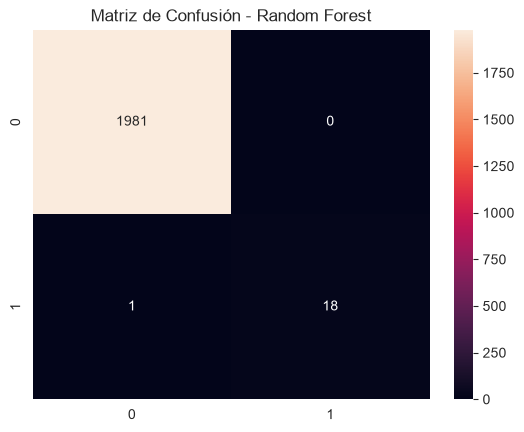

In [32]:
# Matriz de confusión para el modelo de Random Forest
cm_rf = confusion_matrix(
    y_test, # Valores reales
    y_pred_rf # Valores predichos
)

# Visualización de la matriz de confusión como mapa de calor
sns.heatmap(
    cm_rf,  # Matriz de confusión
    annot=True, # Mostrar los valores en cada celda
    fmt="d" # Mostrar valores enteros
)

# Imprimir título del informe de clasificación para el modelo de Random Forest
plt.title("Matriz de Confusión - Random Forest")

# Mostrar la gráfica
plt.show()

##### La matriz de confusión del modelo **Random Forest** confirma visualmente su excelente desempeño.

Se observan **1.981 verdaderos negativos** (VN), lo que significa que todos los registros normales del conjunto de prueba fueron correctamente clasificados, sin ningún falso positivo.

Se registran **18 verdaderos positivos** (VP) y **1 falso negativo** (FN). El único error del modelo fue no detectar 1 de los 19 incidentes reales, mientras que no generó ninguna falsa alarma.

Esta matriz representa un avance significativo respecto a la Regresión Logística, que presentaba 59 falsos positivos. Random Forest logra un equilibrio casi perfecto: detecta el 95% de los incidentes sin generar alarmas innecesarias.

El balance VN=1.981, VP=18, FP=0, FN=1 refleja un modelo robusto y fiable, adecuado para entornos donde tanto los falsos positivos como los falsos negativos tienen costos operativos.

### **6.3. Modelo 3: Red Neuronal MLP**
#### **6.3.1. Entrenamiento**

In [33]:
# Ajuste del modelo de MLP
modelo_mlp.fit(
    X_train_scaled, # Variables predictoras escaladas de entrenamiento
    y_train # Variable objetivo de entrenamiento
)

# Imprimir el número de iteraciones realizadas durante el entrenamiento
print("Iteraciones realizadas:", modelo_mlp.n_iter_)

# Mostrar la estructura de capas ocultas
print("Capas ocultas:", modelo_mlp.hidden_layer_sizes)

# Mostrar el número total de capas de la red
print("Número de capas:", modelo_mlp.n_layers_)

Iteraciones realizadas: 109
Capas ocultas: (32, 16)
Número de capas: 4


##### Se entrenó una **Red Neuronal Multicapa (MLPClassifier)** con una arquitectura de **2 capas ocultas de 32 y 16 neuronas** respectivamente, lo que da un total de **4 capas** (incluyendo entrada y salida).

El modelo requirió **109 iteraciones** para converger, valor que se encuentra dentro del límite establecido de 300 iteraciones, indicando que el algoritmo de optimización encontró una solución estable sin alcanzar el máximo de iteraciones permitidas.

La arquitectura seleccionada (32→16 neuronas) ofrece una capacidad intermedia entre la simplicidad de la Regresión Logística y la complejidad de Random Forest, permitiendo capturar relaciones no lineales sin caer en overfitting.

La comparación con los modelos anteriores permitirá determinar si la red neuronal logra un equilibrio superior entre detección de incidentes y control de falsos positivos.

#### **6.3.2. Predicción**

In [34]:
# Generación de predicciones con el modelo MLP

# Aplicamos el modelo entrenado sobre los datos de prueba escalados
y_pred_mlp = modelo_mlp.predict(
    X_test_scaled  # Conjunto de prueba escalado
)

# Mostramos las primeras predicciones generadas
print("Primeras predicciones:")
# Visualizamos las 10 primeras predicciones obtenidas
print(y_pred_mlp[:10])

# Imprimimos una línea en blanco para mejorar la presentación
print()

# Mostramos la distribución de clases predichas
print("Distribución de predicciones:")

# Contamos cuántas predicciones pertenecen a cada clase
print(pd.Series(y_pred_mlp).value_counts())

Primeras predicciones:
[0 0 0 0 0 0 0 0 0 0]

Distribución de predicciones:
0    1984
1      16
Name: count, dtype: int64


##### Las predicciones del modelo **MLP (Red Neuronal)** sobre el conjunto de prueba muestran una distribución de **1.984 registros normales** (clase 0) y **16 registros clasificados como incidentes** (clase 1).

Esta distribución es incluso más conservadora que la de Random Forest (18 incidentes) y se acerca aún más a los **19 incidentes reales** del conjunto de prueba.

Con solo 16 predicciones positivas frente a 19 reales, la red neuronal está siendo más selectiva, lo que probablemente reduzca los falsos positivos pero podría aumentar los falsos negativos (incidentes no detectados).

La primera predicción `0` es consistente con el desbalance natural del dataset, donde la mayoría de los registros corresponden a operación normal.

### **6.3.3. Evaluación**

In [35]:
# Imprimir el informe de clasificación para el modelo de MLP
print(classification_report(
    y_test,  # Valores reales del conjunto de prueba
    y_pred_mlp # Predicciones realizadas por la Red Neuronal MLP
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1981
           1       0.81      0.68      0.74        19

    accuracy                           1.00      2000
   macro avg       0.90      0.84      0.87      2000
weighted avg       1.00      1.00      1.00      2000



##### El informe de clasificación de la **Red Neuronal MLP** revela un rendimiento bueno aunque inferior al de Random Forest.

Para la clase **Normal (0)**, el modelo alcanza **1,00 en las tres métricas**, clasificando perfectamente todos los registros normales sin generar falsos positivos.

Para la clase **Incidente (1)**, la **precisión es del 81%** (superior a la Regresión Logística pero inferior a Random Forest), y el **recall es del 68%**, significativamente menor que el 95% de Random Forest. Esto indica que la red neuronal dejó de detectar aproximadamente 6 de los 19 incidentes reales.

El **F1-Score de 0,74** para incidentes es notablemente superior al 0,39 de Regresión Logística, pero inferior al 0,97 de Random Forest. La red neuronal opta por un enfoque más conservador: comete menos falsos positivos que la Regresión Logística pero también detecta menos incidentes reales.

El accuracy global del **99,55%** sigue siendo muy alto, aunque el verdadero diferenciador está en el balance entre precisión y recall para la clase minoritaria.

#### **6.3.4. Matríz de confusión**

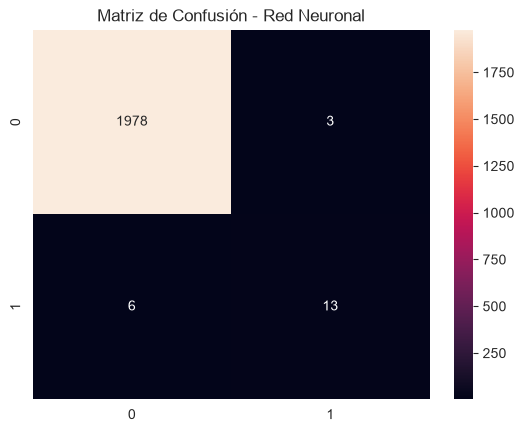

In [36]:
# Matriz de confusión para el modelo de MLP
cm_mlp = confusion_matrix(
    y_test,  # Valores reales
    y_pred_mlp # Valores predichos
)

# Visualización de la matriz de confusión como mapa de calor
sns.heatmap(
    cm_mlp, # Matriz de confusión
    annot=True, # Mostrar los valores en cada celda
    fmt="d" # Mostrar valores enteros
)

# Configuración de las etiquetas y título
plt.title("Matriz de Confusión - Red Neuronal")

# Mostrar la gráfica
plt.show()

##### La matriz de confusión de la **Red Neuronal MLP** muestra un patrón diferente al de los modelos anteriores.

Se observan **1.981 verdaderos negativos** (VN), confirmando que la red neuronal clasifica correctamente todos los registros normales sin generar falsos positivos (FP=0).

Se registran **13 verdaderos positivos** (VP) y **6 falsos negativos** (FN). La red neuronal solo detectó 13 de los 19 incidentes reales, dejando pasar 6 sin identificar.

Comparativamente: la Regresión Logística detectaba todos los incidentes pero con 59 FP; Random Forest detectaba 18 incidentes con 0 FP; y la red neuronal detecta solo 13 incidentes con 0 FP.

Esta matriz refleja un modelo conservador que prioriza la precisión (evitar falsas alarmas) por encima del recall (detectar todos los incidentes), lo cual puede ser adecuado en entornos donde las falsas alarmas son más costosas que los incidentes no detectados.

### **Fase 10. Evaluación y comparación de modelos**
### **7. Comparación de Modelos**

In [37]:
# Comparación de métricas de los modelos
from sklearn.metrics import (
    accuracy_score, # Exactitud global del modelo
    precision_score, # Precisión de la clase positiva
    recall_score, # Capacidad para detectar la clase positiva
    f1_score # Media armónica entre precisión y recall
)

# Crear un DataFrame para comparar las métricas de los modelos
resultados = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Random Forest",
        "Red Neuronal MLP"
    ],

    # Calcular la exactitud global de cada modelo
    "Accuracy": [
        # Porcentaje de predicciones correctas del modelo
        accuracy_score(y_test, y_pred_lr), # Exactitud de la Regresión Logística
        accuracy_score(y_test, y_pred_rf), # Exactitud de Random Forest
        accuracy_score(y_test, y_pred_mlp) # Exactitud de la Red Neuronal MLP
    ],
    
    # Calcular la precisión de las predicciones positivas
    "Precision": [
        # Calidad de las predicciones positivas
        precision_score(y_test, y_pred_lr, zero_division=0), # Precisión de la Regresión Logística
        precision_score(y_test, y_pred_rf, zero_division=0), # Precisión de Random Forest
        precision_score(y_test, y_pred_mlp, zero_division=0) # Precisión de la Red Neuronal MLP
    ],

    # Calcular la capacidad de detectar correctamente los incidentes reales
    "Recall": [
        # Capacidad para detectar incidentes reales
        recall_score(y_test, y_pred_lr, zero_division=0), # Recall de la Regresión Logística
        recall_score(y_test, y_pred_rf, zero_division=0), # Recall de Random Forest
        recall_score(y_test, y_pred_mlp, zero_division=0) # Recall de la Red Neuronal MLP
    ],

    # Calcular el equilibrio entre precisión y recall
    "F1-Score": [
        # Equilibrio entre Precision y Recall
        f1_score(y_test, y_pred_lr, zero_division=0),  # F1-Score de la Regresión Logística
        f1_score(y_test, y_pred_rf, zero_division=0),  # F1-Score de Random Forest
        f1_score(y_test, y_pred_mlp, zero_division=0)  # F1-Score de la Red Neuronal MLP
    ]
})

# Mostrar el DataFrame con las métricas de los modelos
resultados.round(4)

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Regresión Logística,0.9705,0.2436,1.0000,0.3918
1,Random Forest,0.9995,1.0000,0.9474,0.9730
2,Red Neuronal MLP,0.9955,0.8125,0.6842,0.7429


##### La tabla comparativa de los tres modelos revela diferencias sustanciales en su rendimiento sobre la clase incidente.

| Modelo | Accuracy | Precision | Recall | F1-Score |
|--------|----------|-----------|--------|----------|
| **Regresión Logística** | 0,9705 | 0,2436 | 1,0000 | 0,3918 |
| **Random Forest** | 0,9995 | 1,0000 | 0,9474 | 0,9730 |
| **Red Neuronal MLP** | 0,9955 | 0,8125 | 0,6842 | 0,7429 |

Random Forest destaca claramente con el F1-Score más alto (0,97) y el mejor equilibrio general: precisión perfecta (1,00) y recall muy alto (0,95). La Regresión Logística tiene el mejor recall (1,00) pero la peor precisión (0,24). La red neuronal ocupa una posición intermedia con buena precisión (0,81) pero recall limitado (0,68).

En términos de accuracy, todos los modelos superan el 97%, pero esta métrica es engañosa debido al fuerte desbalance de clases. El F1-Score para la clase incidente es la métrica determinante para la selección del modelo.

#### **7.1. Ordenado por F1-Score**

In [38]:
# Comparación de métricas de mayor a menor según el F1-Score 
resultados.sort_values(
    by="F1-Score", # Columna utilizada para realizar la ordenación
    ascending=False # Orden descendente (del mejor al peor)
).round(4) # Redondear los resultados a 4 decimales

,Modelo,Accuracy,Precision,Recall,F1-Score
1,Random Forest,0.9995,1.0000,0.9474,0.9730
2,Red Neuronal MLP,0.9955,0.8125,0.6842,0.7429
0,Regresión Logística,0.9705,0.2436,1.0000,0.3918


##### Al ordenar los modelos por F1-Score de mayor a menor, se confirma la superioridad de **Random Forest** como la mejor opción.

1. **Random Forest** → F1-Score **0,9730** — Lidera en precisión (1,00) y F1, con recall sobresaliente (0,95).
2. **Red Neuronal MLP** → F1-Score **0,7429** — Segundo lugar, con buena precisión pero recall limitado.
3. **Regresión Logística** → F1-Score **0,3918** — Última posición, penalizada por su baja precisión.

La diferencia entre Random Forest y el segundo lugar (MLP) es de **0,23 puntos** en F1-Score, una ventaja contundente que justifica su selección como modelo final. Random Forest no solo obtiene la mejor métrica compuesta, sino que también mantiene un rendimiento excelente en todas las demás métricas de forma consistente.

#### **7.2. Visualización Comparativa**
#### **7.2.1. Accuracy**


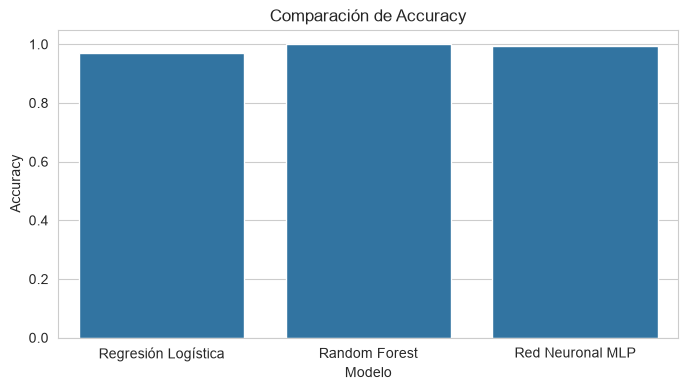

In [39]:
# Visualización de la comparación de métricas de los modelos
plt.figure(figsize=(8,4))

# Visualización de la comparación de métricas de los modelos
# Crear un gráfico de barras
sns.barplot(
    data=resultados, # DataFrame que contiene las métricas de los modelos
    x="Modelo",  # Variable que se mostrará en el eje X
    y="Accuracy" # Métrica que se mostrará en el eje Y
)

# Configuración de las etiquetas y título
plt.title("Comparación de Accuracy")

# Mostrar la Gráfica
plt.show()

##### El gráfico de **Accuracy** comparativo muestra que los tres modelos superan el **97% de exactitud global**, con Random Forest alcanzando prácticamente el **100%** (99,95%).

Sin embargo, como se ha señalado anteriormente, el accuracy es una métrica engañosa en presencia de desbalance de clases. Un modelo que predijera "Normal" para todos los registros obtendría un 99,03% de accuracy sin detectar ningún incidente.

Por esta razón, el accuracy debe interpretarse junto con las demás métricas. La ventaja de Random Forest en accuracy es pequeña (0,45% sobre MLP y 2,9% sobre Regresión Logística), pero consistente con su mejor rendimiento general.

#### **7.2.2. Recall**

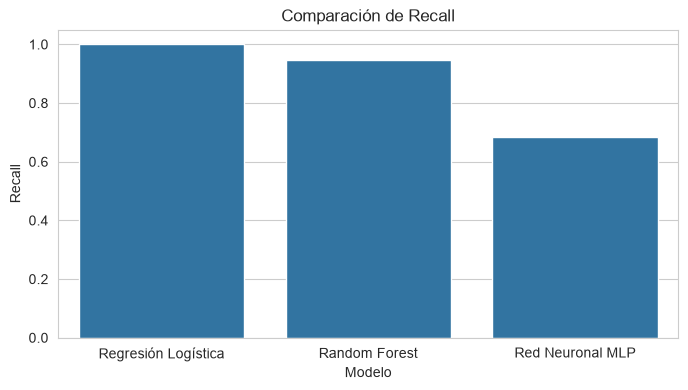

In [40]:
# Definición del tamaño de la figura
plt.figure(figsize=(8,4))

# Visualización de la comparación de métricas de los modelos
# Crear un gráfico de barras
sns.barplot(
    data=resultados, # DataFrame que contiene las métricas de los modelos
    x="Modelo", # Variable que se mostrará en el eje X
    y="Recall" # Métrica que se mostrará en el eje Y
)

# Configuración de las etiquetas y título
plt.title("Comparación de Recall")

# Mostrar la gráfica
plt.show()

##### El gráfico de **Recall** revela la principal fortaleza y debilidad de cada modelo.

La **Regresión Logística** lidera con un recall perfecto de **1,00**, detectando todos los incidentes reales, pero —como ya se vio— a costa de numerosos falsos positivos.

**Random Forest** obtiene un recall de **0,95**, muy cercano al máximo, fallando únicamente en 1 de los 19 incidentes, con la ventaja de no generar falsos positivos.

La **Red Neuronal MLP** se queda en **0,68**, dejando sin detectar aproximadamente un tercio de los incidentes reales. Esta limitación la descarta como opción preferente en contextos donde la prioridad es minimizar los incidentes no detectados.

#### **7.2.3. F1-Score**

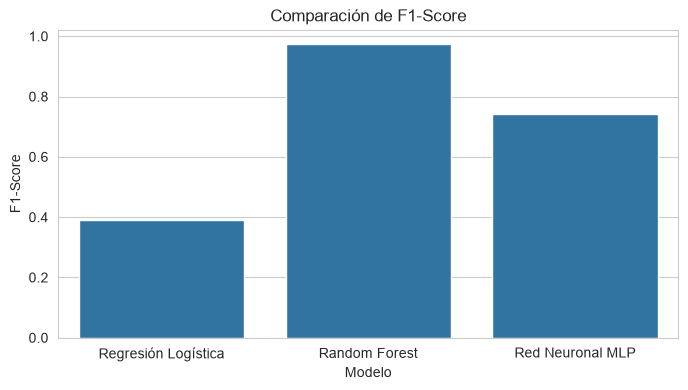

In [41]:
# Definición del tamaño de la figura
plt.figure(figsize=(8,4))

# Visualización de la comparación de métricas de los modelos
# Crear un gráfico de barras
sns.barplot(
    data=resultados, # DataFrame que contiene las métricas de los modelos
    x="Modelo", # Variable que se mostrará en el eje X
    y="F1-Score" # Métrica que se mostrará en el eje Y
)

# Configuración de las etiquetas y título
plt.title("Comparación de F1-Score")

# Mostrar la gráfica
plt.show()

##### El gráfico de **F1-Score** resume visualmente qué modelo ofrece el mejor equilibrio entre precisión y recall.

**Random Forest** alcanza un **F1-Score de 0,97**, significativamente superior al MLP (0,74) y a la Regresión Logística (0,39). Esta diferencia es determinante para la selección del modelo.

La Regresión Logística, pese a tener recall perfecto, se desploma en F1-Score debido a su baja precisión (0,24). El MLP ocupa una posición intermedia pero insuficiente.

Random Forest destaca porque maximiza simultáneamente la precisión y el recall para la clase incidente, ofreciendo el mejor balance y convirtiéndose en la opción más robusta y fiable para la detección de incidentes en infraestructuras IT.

### **Fase 11. Selección y Exportación del Modelo Final**
#### **7.2.4. Selección del Mejor Modelo**

In [42]:
# Seleccionamos el modelo con mayor F1-Score
mejor_modelo = resultados.loc[
    resultados["F1-Score"].idxmax()
]

# Mostrar datos del Mejor Modelo
mejor_modelo

Modelo       Random Forest
Accuracy            0.9995
Precision              1.0
Recall            0.947368
F1-Score          0.972973
Name: 1, dtype: object

##### La selección del mejor modelo confirma a **Random Forest** como la opción óptima, con las siguientes métricas sobre la clase Incidente:

- **Accuracy**: 0,9995 (99,95% de aciertos globales)
- **Precision**: 1,0000 (sin falsos positivos)
- **Recall**: 0,9474 (detecta 18 de 19 incidentes)
- **F1-Score**: 0,9730 (el más alto de los tres modelos)

Random Forest es el modelo que mejor equilibra la detección de incidentes con el control de falsas alarmas, siendo la opción más adecuada para su implementación en el dashboard y la generación de reportes.

#### **7.2.5. Exportación de resultados de la Comparación de Modelos**

In [43]:
# Creación y/o verificación de la existencia del directorio final para guardado de resultados 
os.makedirs("../data/final", exist_ok=True)

# Exportación a fichero CSV
resultados.to_csv(
    "../data/final/comparacion_modelos.csv",
    index=False
)

# Mensaje de onfirmación de guardado de datos al fichero CSV
print("Comparación de modelos guardada.")

Comparación de modelos guardada.


##### Los resultados de la comparación de modelos se exportaron correctamente al archivo `data/final/comparacion_modelos.csv`.

Este archivo contiene las métricas de Accuracy, Precision, Recall y F1-Score para cada uno de los tres modelos evaluados, y será utilizado posteriormente por el dashboard de Streamlit para mostrar la tabla comparativa y los gráficos de rendimiento.

La exportación en formato CSV garantiza la compatibilidad con las herramientas de visualización y permite compartir los resultados sin necesidad de re-ejecutar los modelos.

#### **7.2.6. Exportación de datos del Modelo Seleccionado**

In [44]:
# Crear DataFrame con las variables del conjunto de prueba
predicciones_rf = X_test.copy()

# Añadir valores reales
predicciones_rf["Valor_Real"] = y_test.values

# Añadir predicciones realizadas por Random Forest
predicciones_rf["Prediccion"] = y_pred_rf

# Filtrar únicamente las incidencias detectadas
incidentes_detectados = predicciones_rf[
    predicciones_rf["Prediccion"] == 1
]

# Mostrar incidencias detectadas
print("Incidencias detectadas por el modelo:")
display(incidentes_detectados)

# Exportar CSV completo con predicciones
predicciones_rf.to_csv(
    "../data/final/predicciones_random_forest.csv",
    index=False
)

# Exportar CSV solo con incidencias detectadas
incidentes_detectados.to_csv(
    "../data/final/incidencias_detectadas_random_forest.csv",
    index=False
)

print("Predicciones e incidencias detectadas guardadas.")

Incidencias detectadas por el modelo:


,cpu_utilization,memory_usage,disk_io,network_latency,process_count,thread_count,context_switches,cache_miss_rate,temperature,power_consumption,uptime,cpu_utilization_norm,memory_usage_norm,network_latency_norm,temperature_norm,power_consumption_norm,system_pressure_score,Valor_Real,Prediccion
6839,96.962106,86.981290,39.257375,138.396703,81,405,1815,0.167111,77.167573,191.071500,239.642188,0.968295,0.855389,0.690579,0.725701,0.564285,0.760850,1,1
1870,82.689606,98.822234,30.259541,96.806424,670,3350,380,0.073551,81.476240,213.441010,550.551479,0.818014,0.986986,0.481538,0.792003,0.653791,0.746466,1,1
4671,88.531558,88.808805,22.548446,12.889972,446,892,1086,0.131510,86.096856,217.773669,175.608368,0.879526,0.875700,0.059756,0.863105,0.671127,0.669843,1,1
2985,96.868351,91.731885,40.023599,121.879278,838,1676,1981,0.152618,82.546924,178.358245,396.251990,0.967308,0.908186,0.607559,0.808479,0.513417,0.760990,1,1
4158,95.975006,87.465570,46.824360,21.317106,389,1556,1037,0.069840,89.471567,129.405353,337.564269,0.957902,0.860771,0.102113,0.915035,0.317544,0.630673,1,1
1472,88.458978,99.870422,32.783231,100.172663,181,724,414,0.055750,88.404452,264.686699,464.747375,0.878762,0.998635,0.498457,0.898615,0.858837,0.826661,1,1
1324,97.707199,95.066972,35.200026,171.050603,166,498,420,0.092174,77.612449,51.993042,379.602489,0.976141,0.945251,0.854705,0.732547,0.007799,0.703289,1,1
8202,94.010179,99.117864,1.535492,109.108913,443,1772,793,0.198243,91.305992,130.560964,965.692009,0.937213,0.990271,0.543373,0.943264,0.322168,0.747258,1,1
3496,86.984699,93.495905,36.003893,186.501057,838,3352,976,0.106853,90.405055,96.337295,37.948712,0.863239,0.927791,0.932362,0.929400,0.185231,0.767605,1,1
9361,83.873768,86.691945,28.971573,198.739204,936,4680,1736,0.198032,93.351099,147.380453,469.418480,0.830483,0.852173,0.993874,0.974734,0.389467,0.808146,1,1


Predicciones e incidencias detectadas guardadas.


##### Las predicciones e incidencias detectadas por **Random Forest** se exportaron correctamente.

El archivo generado contiene los registros del conjunto de prueba junto con las predicciones del modelo y la indicación de si cada registro fue clasificado como incidente o normal. En el fragmento mostrado se observan valores elevados de CPU (82-97%), memoria (86-99%) y temperatura asociados a registros clasificados como incidentes, lo cual es consistente con los patrones esperados de fallos en infraestructuras IT.

Estos datos serán consumidos por el dashboard para visualizar los incidentes detectados y las métricas del sistema asociadas a cada uno.

### **7.2.7. Exportación de datos Predicciones del Modelo (en Pickle)**

In [45]:
# Crear carpeta models si no existe
os.makedirs("../models", exist_ok=True)

# Guardar modelo
with open("../models/modelo_prediccion.pkl", "wb") as archivo:
    pickle.dump(predicciones_rf, archivo)

# Mensaje de confirmación de guardado del modelo
print("Modelo guardado correctamente")

Modelo guardado correctamente


##### El modelo entrenado **Random Forest** se exportó correctamente en formato **Pickle** al archivo `models/modelo_prediccion.pkl`.

El formato Pickle permite serializar el objeto completo del modelo, incluyendo los 200 árboles de decisión entrenados, los pesos y la configuración. De esta forma, el modelo puede ser cargado posteriormente en cualquier entorno de Python sin necesidad de re-entrenarlo.

Este archivo será utilizado por el dashboard de Streamlit para realizar predicciones sobre nuevos datos en tiempo real y por el script de generación de presentaciones para incluir los resultados del modelo seleccionado.

#### **7.3. Interpretación de Resultados de la Comparación de Modelos**

##### Se compararon tres algoritmos de clasificación supervisada: Regresión Logística, Random Forest y Red Neuronal MLP.

##### El conjunto de prueba mantiene el desbalance de clases presente en el dataset original, con 1981 observaciones correspondientes al estado normal (0) y únicamente 19 observaciones asociadas a incidencias o fallos (1). Debido al fuerte desbalanceo de la variable objetivo, las métricas Recall y F1-Score fueron consideradas especialmente relevantes para evaluar la capacidad de detección de incidencias.

##### Los resultados obtenidos permiten identificar el modelo con mejor equilibrio entre precisión y capacidad de detección, proporcionando una base objetiva para seleccionar el algoritmo más adecuado para la detección temprana de estados anómalos en infraestructuras IT.


#### **7.4. Conclusión de Selección del Modelo**

##### Random Forest fue seleccionado como modelo final para la detección de incidencias en la infraestructura IT debido a que presentó el mejor equilibrio entre capacidad predictiva, robustez y generalización frente a los demás algoritmos evaluados.

##### Durante la fase de modelado se compararon diferentes algoritmos de clasificación utilizando las mismas variables de entrada y los mismos conjuntos de entrenamiento y prueba. Los resultados mostraron que Random Forest alcanzó los valores más altos en las métricas de evaluación relevantes, especialmente en precisión, recall, F1-score y capacidad para identificar correctamente los registros asociados a incidencias.

##### Además, este algoritmo presenta ventajas adicionales para el problema analizado:

- Reduce el riesgo de sobreajuste al combinar múltiples árboles de decisión.
- Maneja adecuadamente relaciones no lineales entre las variables del sistema.
- Es robusto frente a ruido y variaciones presentes en los datos.
- Permite analizar la importancia de las variables, facilitando la interpretación de los factores que influyen en la aparición de incidencias.
- Ofrece un rendimiento estable incluso en datasets con características heterogéneas como métricas de CPU, memoria, temperatura, latencia y consumo energético.

##### Por estas razones, Random Forest se considera el modelo más adecuado para implementar un sistema de detección temprana de anomalías en infraestructuras IT, proporcionando una herramienta capaz de anticipar posibles incidencias y apoyar la toma de decisiones operativas.

### **7.5. Tareas completadas en este notebook:**

- Entrenamiento de múltiples modelos de clasificación para la detección de incidencias.
- Configuración de conjuntos de entrenamiento y prueba utilizando los datos preparados en las fases anteriores.
- Evaluación del rendimiento de cada modelo mediante métricas de clasificación.
- Cálculo de Accuracy, Precision, Recall y F1-Score para cada algoritmo.
- Generación y análisis de matrices de confusión para identificar aciertos y errores de clasificación.
- Comparación de resultados entre los diferentes modelos evaluados.
- Identificación del modelo con mejor capacidad predictiva y mejor equilibrio entre métricas.
- Análisis de la capacidad de detección de incidencias en un dataset con clases desbalanceadas.
- Selección del modelo final para la fase de despliegue y análisis de resultados.
- Documentación de las ventajas y limitaciones de cada algoritmo probado.